# Calculator for statistical maximum activations to select channels

In [26]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import torch


def image_paths(folder):
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

    return sorted(
        p for p in Path(folder).glob("*")
        if p.suffix.lower() in extensions
    )


def image_to_model_tensor(path, learn, device):
    img = PILImage.create(path)
    dl = learn.dls.test_dl([img])
    return next(iter(dl))[0].to(device)

In [27]:
from settings import categories
image_categories = {}
for axis in categories:
    image_categories[axis] = list(categories[axis].keys())
image_categories

{'depth': ['iconic', 'symbolic'], 'breath': ['abstract', 'concrete']}

In [ ]:
class_folders = {
    "breadth": {
        "abstract": Path("artefacts/breadth/abstract"),
        "concrete": Path("artefacts/breadth/concrete"),
    },
    "depth": {
        "iconic": Path("artefacts/depth/iconic"),
        "symbolic": Path("artefacts/depth/symbolic"),
    },
}

## Load models

In [29]:
from fastai.vision.all import *
# Load a pretrained/pretuned model to visually analyse
model_name = "googlenet"
model_root = f"models/{model_name}_10x"
model_focus = list(categories.keys())
learners = {}
for focus in model_focus:
    learners[focus] = load_learner(f"{model_root}/{focus}.pkl")

/home/trpquo/miniforge3/envs/fastai/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [30]:
device = next(iter(learners.values())).model.parameters().__next__().device

In [16]:
def get_module_by_name(model, name):
    for module_name, module in model.named_modules():
        if module_name == name:
            return module

    raise KeyError(f"Layer not found: {name}")


def top_channels_by_mean_activation(
    model,
    layer_name,
    img_tensor,
    top_n=4,
):
    layer = get_module_by_name(model, layer_name)
    activations = {}

    def hook_fn(module, inputs, output):
        activations["value"] = output.detach()

    hook = layer.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        _ = model(img_tensor)

    hook.remove()

    a = activations["value"]

    if a.ndim != 4:
        raise ValueError(
            f"Expected N x C x H x W activation, got {tuple(a.shape)}"
        )

    channel_means = a.mean(dim=(0, 2, 3))
    values, indices = torch.topk(
        channel_means,
        k=min(top_n, channel_means.numel()),
    )

    return indices.tolist(), values.tolist()

In [18]:
def get_inception_blocks(model):
    blocks = []

    for name, module in model.named_modules():
        if name == "":
            continue

        class_name = module.__class__.__name__.lower()

        if "inception" in class_name and len(list(module.children())) >= 2:
            blocks.append((name, module))

    return blocks

In [19]:
module_names = {
    "0.5": "Inception3a",
    "0.6": "Inception3b",
    "0.8": "Inception4a",
    "0.9": "Inception4b",
    "0.10": "Inception4c",
    "0.11": "Inception4d",
    "0.12": "Inception4e",
    "0.14": "Inception5a",
    "0.15": "Inception5b",
}
for focus, learn in learners.items():
    blocks = get_inception_blocks(learn.model)

    print(f"\n{focus}")
    for i, (name, module) in enumerate(blocks):
        print(f"{i:02d} -> {name}: {module_names[name]}")


depth
00 -> 0.5: Inception3a
01 -> 0.6: Inception3b
02 -> 0.8: Inception4a
03 -> 0.9: Inception4b
04 -> 0.10: Inception4c
05 -> 0.11: Inception4d
06 -> 0.12: Inception4e
07 -> 0.14: Inception5a
08 -> 0.15: Inception5b

breath
00 -> 0.5: Inception3a
01 -> 0.6: Inception3b
02 -> 0.8: Inception4a
03 -> 0.9: Inception4b
04 -> 0.10: Inception4c
05 -> 0.11: Inception4d
06 -> 0.12: Inception4e
07 -> 0.14: Inception5a
08 -> 0.15: Inception5b


## Collect channel means

In [3]:
def collect_layer_channel_means(
    model,
    learn,
    layer_name,
    labeled_paths,
    device,
):
    model.eval()

    layer = get_module_by_name(model, layer_name)
    captured = {}

    def hook_fn(module, inputs, output):
        captured["value"] = output.detach()

    hook = layer.register_forward_hook(hook_fn)

    rows = []

    with torch.no_grad():
        for path, class_name in labeled_paths:
            xb = image_to_model_tensor(path, learn, device)
            _ = model(xb)

            a = captured["value"]

            if a.ndim != 4:
                raise ValueError(
                    f"Expected N x C x H x W, got {tuple(a.shape)}"
                )

            channel_means = a.mean(dim=(0, 2, 3)).cpu().numpy()

            row = {
                "path": str(path),
                "class": class_name,
            }

            row.update({
                f"ch{c:04d}": float(value)
                for c, value in enumerate(channel_means)
            })

            rows.append(row)

    hook.remove()

    return pd.DataFrame(rows)

In [4]:
def labeled_image_paths(focus):
    records = []

    for class_name, folder in class_folders[focus].items():
        for path in image_paths(folder):
            records.append((path, class_name))

    return records

In [23]:
def top_channels_for_class(ranked_df, class_name, top_n=8):
    result = ranked_df.copy()

    result["target_direction"] = np.where(
        result["mean_a"] > result["mean_b"],
        result["class_a"],
        result["class_b"],
    )

    return result.loc[
        result["target_direction"] == class_name
    ].head(top_n)

## Analyze all Inception modules

### Collect activation means for all channels

In [57]:
def collect_all_layer_channel_means(
    focus,
    learners,
    class_folders,
    device,
    max_images_per_class=None,
):
    learn = learners[focus]
    model = learn.model
    model.eval()

    records = []

    for class_name, folder in class_folders[focus].items():
        paths = image_paths(folder)

        if max_images_per_class is not None:
            paths = paths[:max_images_per_class]

        records.extend(
            (path, class_name)
            for path in paths
        )

    all_layer_dfs = {}

    for layer_name, module in get_inception_blocks(model):
        print(f"Collecting {focus} / {module_names[layer_name]}")

        df = collect_layer_channel_means(
            model=model,
            learn=learn,
            layer_name=layer_name,
            labeled_paths=records,
            device=device,
        )

        df.insert(0, "focus", focus)
        df.insert(1, "layer_name", layer_name)
        df.insert(2, "module_name", module_names[layer_name])

        all_layer_dfs[(focus, layer_name)] = df

    return all_layer_dfs

In [58]:
all_activation_dfs = {}

for focus in learners:
    result = collect_all_layer_channel_means(
        focus=focus,
        learners=learners,
        class_folders=class_folders,
        device=device,
        max_images_per_class=None,
    )

    all_activation_dfs.update(result)

### Cohen's *d* classifier-alignment measure

Cohen’s *d* identifies channels whose mean activations differ by class. A separate question is whether those activations predict the class label.

For each layer, fit a simple logistic regression using individual channel means as features: $\hat{y} = \sigma(w^Tm+b)$

The learned coefficient *w_c* measures the direction in which channel *c* contributes to a linear class separation in that layer’s representation.

In [59]:
def rank_channels_by_cohens_d(channel_df):
    class_values = channel_df["class"].unique()

    if len(class_values) != 2:
        raise ValueError(
            f"Expected exactly two classes, got {class_values}"
        )

    class_a, class_b = class_values
    channel_names = [
        c for c in channel_df.columns
        if c.startswith("ch")
    ]

    rows = []

    for channel_name in channel_names:
        a = channel_df.loc[
            channel_df["class"] == class_a,
            channel_name,
        ].to_numpy()

        b = channel_df.loc[
            channel_df["class"] == class_b,
            channel_name,
        ].to_numpy()

        mean_a = a.mean()
        mean_b = b.mean()
        std_a = a.std(ddof=1)
        std_b = b.std(ddof=1)

        pooled_std = np.sqrt(
            0.5 * (std_a ** 2 + std_b ** 2)
        )

        d = (
            (mean_a - mean_b) / pooled_std
            if pooled_std > 1e-12
            else 0.0
        )

        rows.append({
            "channel": int(channel_name[2:]),
            "class_a": class_a,
            "class_b": class_b,
            "mean_a": mean_a,
            "mean_b": mean_b,
            "std_a": std_a,
            "std_b": std_b,
            "cohens_d": d,
            "abs_cohens_d": abs(d),
        })

    return pd.DataFrame(rows).sort_values(
        "abs_cohens_d",
        ascending=False,
    ).reset_index(drop=True)

In [60]:
all_ranking_dfs = []

for (focus, layer_name), activation_df in all_activation_dfs.items():
    ranking = rank_channels_by_cohens_d(activation_df)

    ranking.insert(0, "focus", focus)
    ranking.insert(1, "layer_name", layer_name)

    all_ranking_dfs.append(ranking)

all_rankings = pd.concat(
    all_ranking_dfs,
    ignore_index=True,
)

In [61]:
all_rankings.to_parquet(root / "output/all_channel_rankings.parquet")
all_rankings[
    ["focus", "layer_name", "channel", "cohens_d", "abs_cohens_d"]
].head()

,focus,layer_name,channel,cohens_d,abs_cohens_d
0,depth,0.5,249,0.751991,0.751991
1,depth,0.5,66,0.706396,0.706396
2,depth,0.5,142,-0.657480,0.657480
3,depth,0.5,156,-0.569068,0.569068
4,depth,0.5,164,-0.562420,0.562420


## Linear  probes 

In [62]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

In [65]:
def linear_channel_probe(channel_df):
    channel_names = [
        c for c in channel_df.columns
        if c.startswith("ch")
    ]

    X = channel_df[channel_names].to_numpy()
    y = channel_df["class"].astype("category").cat.codes.to_numpy()

    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            solver="liblinear",
        ),
    )

    probe.fit(X, y)

    classifier = probe[-1]
    coefficients = classifier.coef_[0]

    result = pd.DataFrame({
        "channel": [int(c[2:]) for c in channel_names],
        "probe_coefficient": coefficients,
        "abs_probe_coefficient": np.abs(coefficients),
    }).sort_values(
        "abs_probe_coefficient",
        ascending=False,
    )

    return probe, result

def cross_validated_linear_probe(channel_df, n_splits=5):
    channel_names = [
        c for c in channel_df.columns
        if c.startswith("ch")
    ]

    X = channel_df[channel_names].to_numpy(dtype=np.float32)
    y = channel_df["class"].astype("category").cat.codes.to_numpy()

    class_names = list(
        channel_df["class"].astype("category").cat.categories
    )

    estimator = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            solver="liblinear",
        ),
    )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    accuracy = cross_val_score(
        estimator,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
    )

    balanced_accuracy = cross_val_score(
        estimator,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1,
    )

    auc = cross_val_score(
        estimator,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    )

    return {
        "class_names": class_names,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "roc_auc": auc,
        "accuracy_mean": accuracy.mean(),
        "accuracy_std": accuracy.std(ddof=1),
        "balanced_accuracy_mean": balanced_accuracy.mean(),
        "balanced_accuracy_std": balanced_accuracy.std(ddof=1),
        "roc_auc_mean": auc.mean(),
        "roc_auc_std": auc.std(ddof=1),
    }

In [67]:
all_probe_summaries = []
all_probe_coefficients = []

for (focus, layer_name), activation_df in all_activation_dfs.items():
    print(f"Probing {focus} / {layer_name}")

    probe_result = cross_validated_linear_probe(
        activation_df,
        n_splits=5,
    )

    all_probe_summaries.append({
        "focus": focus,
        "layer_name": layer_name,
        "accuracy_mean": probe_result["accuracy_mean"],
        "accuracy_std": probe_result["accuracy_std"],
        "balanced_accuracy_mean": (
            probe_result["balanced_accuracy_mean"]
        ),
        "balanced_accuracy_std": (
            probe_result["balanced_accuracy_std"]
        ),
        "roc_auc_mean": probe_result["roc_auc_mean"],
        "roc_auc_std": probe_result["roc_auc_std"],
    })

    _, coefficient_df = linear_channel_probe(activation_df)

    coefficient_df.insert(0, "focus", focus)
    coefficient_df.insert(1, "layer_name", layer_name)
    coefficient_df.insert(2, "module_name", module_names[layer_name])

    all_probe_coefficients.append(coefficient_df)

probe_summary_df = pd.DataFrame(all_probe_summaries)

probe_coefficients_df = pd.concat(
    all_probe_coefficients,
    ignore_index=True,
)

Probing depth / 0.5
Probing depth / 0.6
Probing depth / 0.8
Probing depth / 0.9
Probing depth / 0.10
Probing depth / 0.11
Probing depth / 0.12
Probing depth / 0.14
Probing depth / 0.15
Probing breath / 0.5
Probing breath / 0.6
Probing breath / 0.8
Probing breath / 0.9
Probing breath / 0.10
Probing breath / 0.11
Probing breath / 0.12
Probing breath / 0.14
Probing breath / 0.15


In [68]:
probe_summary_df.to_parquet(root / "output/probe_summaries.parquet")
probe_coefficients_df.to_parquet(root / "output/probe_coefficients.parquet")

## Channel ablation on real images

### Ablation for all layers

In [44]:
def class_margin(logits, class_a_index=0, class_b_index=1):
    return (
        logits[:, class_a_index]
        - logits[:, class_b_index]
    )

In [45]:
def ablated_margin_for_image(
    model,
    learn,
    path,
    layer_name,
    channel,
    device,
):
    model.eval()

    xb = image_to_model_tensor(path, learn, device)

    layer = get_module_by_name(model, layer_name)
    state = {"ablate": False}

    def hook_fn(module, inputs, output):
        if not state["ablate"]:
            return output

        modified = output.clone()
        modified[:, channel, :, :] = 0
        return modified

    hook = layer.register_forward_hook(hook_fn)

    with torch.no_grad():
        state["ablate"] = False
        original_logits = model(xb)
        original_margin = class_margin(original_logits)

        state["ablate"] = True
        ablated_logits = model(xb)
        ablated_margin = class_margin(ablated_logits)

    hook.remove()

    return {
        "original_margin": original_margin.item(),
        "ablated_margin": ablated_margin.item(),
        "margin_change": (
            original_margin.item()
            - ablated_margin.item()
        ),
        "original_logits": original_logits.squeeze(0).cpu().numpy(),
        "ablated_logits": ablated_logits.squeeze(0).cpu().numpy(),
    }

In [80]:
def candidate_channels_from_ranking(
    ranking_df,
    top_n=10,
):
    class_a = ranking_df["class_a"].iloc[0]
    class_b = ranking_df["class_b"].iloc[0]

    toward_a = (
        ranking_df[ranking_df["cohens_d"] > 0]
        .head(top_n)
        .assign(target_class=class_a)
    )

    toward_b = (
        ranking_df[ranking_df["cohens_d"] < 0]
        .sort_values("cohens_d", ascending=True)
        .head(top_n)
        .assign(target_class=class_b)
    )

    return pd.concat(
        [toward_a, toward_b],
        ignore_index=True,
    )

In [81]:
candidate_records = []

for (focus, layer_name), ranking in all_rankings.groupby(
    ["focus", "layer_name"],
    sort=False,
):
    candidates = candidate_channels_from_ranking(
        ranking,
        top_n=10,
    ).copy()

    # These columns already exist in `ranking`; do not insert them again.
    candidate_records.append(candidates)

candidate_df = pd.concat(
    candidate_records,
    ignore_index=True,
)

In [82]:
def run_channel_ablation_for_layer(
    focus,
    layer_name,
    channels,
    learners,
    class_folders,
    device,
    max_images_per_class=100,
):
    learn = learners[focus]
    model = learn.model

    rows = []

    for class_name, folder in class_folders[focus].items():
        paths = image_paths(folder)[:max_images_per_class]

        for path in paths:
            for channel in channels:
                result = ablated_margin_for_image(
                    model=model,
                    learn=learn,
                    path=path,
                    layer_name=layer_name,
                    channel=int(channel),
                    device=device,
                )

                rows.append({
                    "focus": focus,
                    "layer_name": layer_name,
                    "module_name": module_names[layer_name],
                    "channel": int(channel),
                    "class": class_name,
                    "path": str(path),
                    **result,
                })

    return pd.DataFrame(rows)

In [84]:
all_ablation_dfs = []

for (focus, layer_name), group in candidate_df.groupby(
    ["focus", "layer_name"]
):
    channels = group["channel"].unique().tolist()

    print(
        f"Ablating {focus} / {layer_name}: "
        f"{len(channels)} channels"
    )

    ablation_result = run_channel_ablation_for_layer(
        focus=focus,
        layer_name=layer_name,
        channels=channels,
        learners=learners,
        class_folders=class_folders,
        device=device,
        max_images_per_class=100,
    )

    all_ablation_dfs.append(ablation_result)

all_ablation_df = pd.concat(
    all_ablation_dfs,
    ignore_index=True,
)

Ablating breath / 0.10: 20 channels


Ablating breath / 0.11: 20 channels
Ablating breath / 0.12: 20 channels
Ablating breath / 0.14: 20 channels
Ablating breath / 0.15: 20 channels
Ablating breath / 0.5: 20 channels
Ablating breath / 0.6: 20 channels
Ablating breath / 0.8: 20 channels
Ablating breath / 0.9: 20 channels
Ablating depth / 0.10: 20 channels
Ablating depth / 0.11: 20 channels
Ablating depth / 0.12: 20 channels
Ablating depth / 0.14: 20 channels
Ablating depth / 0.15: 20 channels
Ablating depth / 0.5: 20 channels
Ablating depth / 0.6: 20 channels
Ablating depth / 0.8: 20 channels
Ablating depth / 0.9: 20 channels


In [85]:
all_ablation_df.to_parquet(root / "output/all_channel_ablation.parquet")

In [20]:
all_ablation_df = pd.read_parquet("output/all_channel_ablation.parquet")

In [22]:
all_ablation_df

,focus,layer_name,module_name,channel,class,path,original_margin,ablated_margin,margin_change,original_logits,ablated_logits
0,breath,0.10,Inception4c,463,abstract,artefacts/breath/abstract/10188.jpg,6.444111,6.490109,-0.045999,"[4.082623, -2.361488]","[4.1052923, -2.3848171]"
1,breath,0.10,Inception4c,219,abstract,artefacts/breath/abstract/10188.jpg,6.444111,6.707118,-0.263007,"[4.082623, -2.361488]","[4.1934953, -2.513623]"
2,breath,0.10,Inception4c,360,abstract,artefacts/breath/abstract/10188.jpg,6.444111,6.135383,0.308728,"[4.082623, -2.361488]","[4.007854, -2.127529]"
3,breath,0.10,Inception4c,371,abstract,artefacts/breath/abstract/10188.jpg,6.444111,6.417990,0.026121,"[4.082623, -2.361488]","[4.0665765, -2.3514135]"
4,breath,0.10,Inception4c,116,abstract,artefacts/breath/abstract/10188.jpg,6.444111,6.037208,0.406903,"[4.082623, -2.361488]","[3.8785055, -2.1587026]"
...,...,...,...,...,...,...,...,...,...,...,...
71995,depth,0.9,Inception4b,26,symbolic,artefacts/depth/symbolic/189820.jpg,-7.341803,-7.093589,-0.248213,"[-3.701674, 3.6401284]","[-3.6953895, 3.3981998]"
71996,depth,0.9,Inception4b,393,symbolic,artefacts/depth/symbolic/189820.jpg,-7.341803,-7.446886,0.105083,"[-3.701674, 3.6401284]","[-3.7711582, 3.675728]"
71997,depth,0.9,Inception4b,148,symbolic,artefacts/depth/symbolic/189820.jpg,-7.341803,-7.124100,-0.217703,"[-3.701674, 3.6401284]","[-3.6164675, 3.5076325]"
71998,depth,0.9,Inception4b,471,symbolic,artefacts/depth/symbolic/189820.jpg,-7.341803,-7.209520,-0.132282,"[-3.701674, 3.6401284]","[-3.739678, 3.4698424]"


In [23]:
def summarize_ablation(
    ablation_df,
    class_a,
    class_b,
):
    """
    Summarize channel-ablation effects separately for two classes.

    Expected columns:
        channel
        class
        margin_change

    `margin_change` is:
        original_margin - ablated_margin
    """

    grouped = (
        ablation_df
        .groupby(["channel", "class"])["margin_change"]
        .agg(["mean", "std", "median", "count"])
    )

    summary = grouped.unstack("class")

    summary.columns = [
        f"{stat}_{class_name}"
        for stat, class_name in summary.columns
    ]

    summary = summary.reset_index()

    summary["signed_ablation_score"] = 0.5 * (
        summary[f"mean_{class_a}"]
        - summary[f"mean_{class_b}"]
    )

    consistency_a = (
        ablation_df[ablation_df["class"] == class_a]
        .groupby("channel")["margin_change"]
        .apply(lambda values: (values > 0).mean())
        .rename("consistency_a")
    )

    consistency_b = (
        ablation_df[ablation_df["class"] == class_b]
        .groupby("channel")["margin_change"]
        .apply(lambda values: (values < 0).mean())
        .rename("consistency_b")
    )

    summary = summary.merge(
        consistency_a,
        on="channel",
        how="left",
    )

    summary = summary.merge(
        consistency_b,
        on="channel",
        how="left",
    )

    summary["consistent_ablation"] = (
        (summary["consistency_a"] >= 0.6)
        & (summary["consistency_b"] >= 0.6)
    )

    return summary

In [24]:
def ordered_classes(focus, learners):
    return list(learners[focus].dls.vocab)

In [31]:
all_ablation_summaries = []

for (focus, layer_name), ablation_group in all_ablation_df.groupby(
    ["focus", "layer_name"],
    sort=False,
):
    classes = list(ablation_group["class"].unique())

    if len(classes) != 2:
        raise ValueError(
            f"{focus}/{layer_name} has classes {classes}, "
            "but exactly two are required."
        )

    class_a, class_b = ordered_classes(focus, learners)

    summary = summarize_ablation(
        ablation_df=ablation_group,
        class_a=class_a,
        class_b=class_b,
    )

    summary.insert(0, "focus", focus)
    summary.insert(1, "layer_name", layer_name)

    all_ablation_summaries.append(summary)

ablation_summary_df = pd.concat(
    all_ablation_summaries,
    ignore_index=True,
)

In [34]:
ablation_summary_df.to_parquet(root / "output/channel_ablation_summary.parquet")
ablation_summary_df.loc[(ablation_summary_df["consistent_ablation"] == True)].head()

,focus,layer_name,channel,mean_abstract,mean_concrete,std_abstract,std_concrete,median_abstract,median_concrete,count_abstract,...,consistency_b,consistent_ablation,mean_iconic,mean_symbolic,std_iconic,std_symbolic,median_iconic,median_symbolic,count_iconic,count_symbolic
53,breath,0.12,640,0.327414,-0.083919,0.346411,0.139011,0.257390,-0.084164,100.0,...,0.75,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,breath,0.12,695,0.465497,-0.117670,0.464717,0.163449,0.341784,-0.124066,100.0,...,0.77,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,breath,0.5,19,2.056924,-0.303857,2.029084,1.400030,1.964157,-0.287281,100.0,...,0.62,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,breath,0.5,40,0.723436,-0.124052,1.239004,0.404038,0.574183,-0.166064,100.0,...,0.62,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144,breath,0.8,108,0.090734,-0.002611,0.474254,0.205919,0.091328,-0.016620,100.0,...,0.60,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Combine all evidence for channel importance

In [35]:
import pandas as pd
from settings import root

In [36]:
all_rankings = pd.read_parquet(root / "output/all_channel_rankings.parquet")
display(all_rankings)
probe_coefficients_df = pd.read_parquet(root / "output/probe_coefficients.parquet")
display(probe_coefficients_df.shape)
ablation_summary_df = pd.read_parquet(root / "output/channel_ablation_summary.parquet")
display(ablation_summary_df.shape)

,focus,layer_name,channel,class_a,class_b,mean_a,mean_b,std_a,std_b,cohens_d,abs_cohens_d
0,depth,0.5,249,iconic,symbolic,0.403465,0.264059,0.209629,0.157445,0.751991,0.751991
1,depth,0.5,66,iconic,symbolic,0.721759,0.596345,0.196504,0.156294,0.706396,0.706396
2,depth,0.5,142,iconic,symbolic,0.194201,0.278318,0.117396,0.137678,-0.657480,0.657480
3,depth,0.5,156,iconic,symbolic,0.279046,0.375748,0.170160,0.169702,-0.569068,0.569068
4,depth,0.5,164,iconic,symbolic,0.445374,0.510099,0.123186,0.106365,-0.562420,0.562420
...,...,...,...,...,...,...,...,...,...,...,...
10971,breath,0.15,13,abstract,concrete,0.347389,0.346098,0.330148,0.239368,0.004477,0.004477
10972,breath,0.15,677,abstract,concrete,0.388930,0.387466,0.332918,0.326423,0.004440,0.004440
10973,breath,0.15,1018,abstract,concrete,0.381392,0.380260,0.330589,0.287413,0.003653,0.003653
10974,breath,0.15,11,abstract,concrete,0.294263,0.293363,0.332354,0.221692,0.003187,0.003187


(10976, 6)

(360, 23)

In [37]:
channel_evidence = all_rankings.merge(
    probe_coefficients_df[
        [
            "focus",
            "layer_name",
            "channel",
            "probe_coefficient",
            "abs_probe_coefficient",
        ]
    ],
    on=["focus", "layer_name", "channel"],
    how="left",
)

channel_evidence = channel_evidence.merge(
    ablation_summary_df,
    on=["focus", "layer_name", "channel"],
    how="left",
)

In [38]:
# check for missing ablation values
channel_evidence[
    "signed_ablation_score"
].isna().mean()

np.float64(0.967201166180758)

### Standardize scores within each layer

In [39]:
def add_within_group_zscores(
    df,
    columns,
    group_columns=("focus", "layer_name"),
):
    result = df.copy()

    for column in columns:
        z_name = f"{column}_z"

        result[z_name] = (
            result
            .groupby(list(group_columns))[column]
            .transform(
                lambda x: (
                    (x - x.mean()) /
                    x.std(ddof=0)
                    if x.std(ddof=0) > 1e-12
                    else 0.0
                )
            )
        )

    return result

In [40]:
channel_evidence = add_within_group_zscores(
    channel_evidence,
    columns=[
        "abs_cohens_d",
        "abs_probe_coefficient",
        "signed_ablation_score",
    ],
)

In [41]:
# final combination of evidence
channel_evidence["combined_evidence_score"] = (
    channel_evidence["abs_cohens_d_z"].fillna(0)
    + channel_evidence["abs_probe_coefficient_z"].fillna(0)
    + channel_evidence["signed_ablation_score_z"].fillna(0)
)

In [42]:
channel_evidence

,focus,layer_name,channel,class_a,class_b,mean_a,mean_b,std_a,std_b,cohens_d,...,std_iconic,std_symbolic,median_iconic,median_symbolic,count_iconic,count_symbolic,abs_cohens_d_z,abs_probe_coefficient_z,signed_ablation_score_z,combined_evidence_score
0,depth,0.5,249,iconic,symbolic,0.403465,0.264059,0.209629,0.157445,0.751991,...,0.351431,0.306816,-0.016911,0.000131,100.0,100.0,3.848672,0.175868,-0.254749,3.769791
1,depth,0.5,66,iconic,symbolic,0.721759,0.596345,0.196504,0.156294,0.706396,...,0.578039,0.469950,0.269068,0.256472,100.0,100.0,3.532440,0.253438,-0.515543,3.270334
2,depth,0.5,142,iconic,symbolic,0.194201,0.278318,0.117396,0.137678,-0.657480,...,0.342545,0.385097,-0.002708,-0.020826,100.0,100.0,3.193177,0.521224,-0.084634,3.629767
3,depth,0.5,156,iconic,symbolic,0.279046,0.375748,0.170160,0.169702,-0.569068,...,0.464063,0.528127,0.044288,-0.138073,100.0,100.0,2.579991,1.639034,2.364039,6.583063
4,depth,0.5,164,iconic,symbolic,0.445374,0.510099,0.123186,0.106365,-0.562420,...,0.555518,0.513810,-0.008033,0.123010,100.0,100.0,2.533879,0.733956,-1.741880,1.525955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10971,breath,0.15,13,abstract,concrete,0.347389,0.346098,0.330148,0.239368,0.004477,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.407608,-0.354643,NaN,-1.762251
10972,breath,0.15,677,abstract,concrete,0.388930,0.387466,0.332918,0.326423,0.004440,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.407738,-0.224368,NaN,-1.632106
10973,breath,0.15,1018,abstract,concrete,0.381392,0.380260,0.330589,0.287413,0.003653,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.410546,-1.027408,NaN,-2.437954
10974,breath,0.15,11,abstract,concrete,0.294263,0.293363,0.332354,0.221692,0.003187,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.412209,0.529624,NaN,-0.882585


In [43]:
channel_evidence.to_parquet(root / "output/channel_importance_evidence.parquet")

### Select channels with consistent evidence

In [44]:
selected_evidence = channel_evidence[
    channel_evidence["signed_ablation_score"].notna()
    & channel_evidence["consistent_ablation"]
    & (channel_evidence["abs_cohens_d"] >= 0.5)
].copy()

In [45]:
selected_evidence = selected_evidence.sort_values(
    [
        "focus",
        "layer_name",
        "combined_evidence_score",
    ],
    ascending=[True, True, False],
)

In [46]:
selected_evidence.to_parquet(root / "output/selected_channel_importance_evidence.parquet")
selected_evidence.groupby(
    ["focus", "layer_name"]
).head(10)

,focus,layer_name,channel,class_a,class_b,mean_a,mean_b,std_a,std_b,cohens_d,...,std_iconic,std_symbolic,median_iconic,median_symbolic,count_iconic,count_symbolic,abs_cohens_d_z,abs_probe_coefficient_z,signed_ablation_score_z,combined_evidence_score
8289,breath,0.12,695,abstract,concrete,0.166691,0.078157,0.077655,0.029954,1.504290,...,NaN,NaN,NaN,NaN,NaN,NaN,3.089010,-0.944423,1.113798,3.258384
8343,breath,0.12,640,abstract,concrete,0.139398,0.092403,0.046977,0.042322,1.051120,...,NaN,NaN,NaN,NaN,NaN,NaN,1.744965,-1.249564,0.544157,1.039558
5498,breath,0.5,19,abstract,concrete,2.629632,1.752215,1.015023,0.476629,1.106565,...,NaN,NaN,NaN,NaN,NaN,NaN,1.877760,-0.520708,4.015099,5.372151
5491,breath,0.5,40,abstract,concrete,0.840395,0.373568,0.526848,0.171851,1.191324,...,NaN,NaN,NaN,NaN,NaN,NaN,2.147959,-0.424941,1.224832,2.947851
6235,breath,0.8,469,abstract,concrete,1.059867,0.550015,0.476501,0.285216,1.298378,...,NaN,NaN,NaN,NaN,NaN,NaN,2.223072,0.585059,1.349294,4.157425
6242,breath,0.8,108,abstract,concrete,0.555004,0.149955,0.423135,0.169668,1.256517,...,NaN,NaN,NaN,NaN,NaN,NaN,2.106373,0.440094,-0.456903,2.089563
6751,breath,0.9,422,abstract,concrete,0.382910,0.111229,0.280040,0.100495,1.291369,...,NaN,NaN,NaN,NaN,NaN,NaN,2.102708,-0.815887,0.161234,1.448055


### Selecting channels for visualizations

In [99]:
def channels_for_class(
    evidence_df,
    focus,
    target_class,
    min_abs_d=0.5,
):
    subset = evidence_df[
        (evidence_df["focus"] == focus)
        & (evidence_df["abs_cohens_d"] >= min_abs_d)
    ].copy()

    if subset.empty:
        return subset

    class_a = subset["class_a"].iloc[0]
    class_b = subset["class_b"].iloc[0]

    if target_class == class_a:
        return subset[subset["cohens_d"] > 0].copy()

    if target_class == class_b:
        return subset[subset["cohens_d"] < 0].copy()

    raise ValueError(
        f"{target_class!r} is not one of "
        f"{class_a!r}, {class_b!r}"
    )

In [ ]:
symbolic_channels = channels_for_class(
    selected_evidence,
    focus="depth",
    target_class="symbolic",
)

iconic_channels = channels_for_class(
    selected_evidence,
    focus="depth",
    target_class="iconic",
)

abstract_channels = channels_for_class(
    selected_evidence,
    focus="breadth",
    target_class="abstract",
)

concrete_channels = channels_for_class(
    selected_evidence,
    focus="breadth",
    target_class="concrete",
)

# Patch occlusion

In [100]:
def load_rgb_tensor(path, device):
    img = Image.open(path).convert("RGB")
    arr = np.asarray(img).astype(np.float32) / 255.0

    x = (
        torch.from_numpy(arr)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .to(device)
    )

    return x

In [101]:
def model_margin(
    model,
    learn,
    x_rgb,
    class_a_index,
    class_b_index,
):
    x_model = preprocess_for_model(x_rgb, learn)
    logits = model(x_model)

    return (
        logits[:, class_a_index]
        - logits[:, class_b_index]
    )

In [129]:
def occlusion_map(
    model,
    learn,
    image_path,
    class_a_index,
    class_b_index,
    patch_size=64,
    stride=32,
    fill="mean",
    device=None,
):
    model.eval()

    if device is None:
        device = next(model.parameters()).device

    x = load_rgb_tensor(image_path, device)
    _, _, height, width = x.shape

    if fill == "mean":
        fill_value = x.mean(dim=(2, 3), keepdim=True)
    elif fill == "gray":
        fill_value = torch.full(
            (1, 3, 1, 1),
            0.5,
            device=device,
        )
    else:
        raise ValueError("fill must be 'mean' or 'gray'")

    with torch.no_grad():
        original_margin = model_margin(
            model,
            learn,
            x,
            class_a_index,
            class_b_index,
        ).item()

    ys = list(range(0, max(height - patch_size, 0) + 1, stride))
    xs = list(range(0, max(width - patch_size, 0) + 1, stride))

    if ys[-1] != height - patch_size:
        ys.append(height - patch_size)

    if xs[-1] != width - patch_size:
        xs.append(width - patch_size)

    result = np.full(
        (len(ys), len(xs)),
        np.nan,
        dtype=np.float32,
    )

    with torch.no_grad():
        for yi, y in enumerate(ys):
            for xi, x0 in enumerate(xs):
                occluded = x.clone()

                occluded[
                    :,
                    :,
                    y:y + patch_size,
                    x0:x0 + patch_size,
                ] = fill_value

                occluded_margin = model_margin(
                    model,
                    learn,
                    occluded,
                    class_a_index,
                    class_b_index,
                ).item()

                result[yi, xi] = (
                    original_margin - occluded_margin
                )

    return {
        "map": result,
        "ys": ys,
        "xs": xs,
        "original_margin": original_margin,
        "patch_size": patch_size,
        "stride": stride,
    }

In [104]:
def preprocess_for_model(x_rgb, learn):
    """
    x_rgb: N x 3 x H x W tensor in [0, 1].
    Returns the tensor expected by learn.model.
    """
    x = x_rgb

    for transform in learn.dls.after_batch.fs:
        x = transform(x)

    return x

In [105]:
depth_learn = learners["depth"]

depth_occ = occlusion_map(
    model=depth_learn.model,
    learn=depth_learn,
    image_path="artefacts/depth/symbolic/225188.jpg",
    class_a_index=1,  # symbolic
    class_b_index=0,  # iconic
    patch_size=64,
    stride=32,
    fill="mean",
    device=device,
)

In [ ]:
breadth_learn = learners["breadth"]

breadth_occ = occlusion_map(
    model=breadth_learn.model,
    learn=breadth_learn,
    image_path="artefacts/breadth/concrete/20713.jpg",
    class_a_index=1,  # concrete
    class_b_index=0,  # abstract
    patch_size=64,
    stride=32,
    fill="mean",
    device=device,
)

In [ ]:
def show_occlusion_map(image_path, result, title=None):
    img = Image.open(image_path).convert("RGB")

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.imshow(img)

    im = ax.imshow(
        result["map"],
        cmap="coolwarm",
        alpha=0.55,
        interpolation="bilinear",
        extent=[
            0,
            img.width,
            img.height,
            0,
        ],
    )

    plt.colorbar(im, ax=ax, label="margin decrease")
    ax.set_title(title or "Patch occlusion")
    ax.axis("off")
    plt.show()

In [139]:
import random

def get_occlusion_records(max_images_per_class=10):
    occlusions = {}
    for axis in categories.keys():
        learn = learners[axis]
        records = []

        for class_name, folder in class_folders[axis].items():
            paths = image_paths(folder)

            if max_images_per_class is not None:
                paths = random.choices(paths, k=max_images_per_class)

            records.extend(
                (path, class_name)
                for path in paths
            )
        
        occlusions[axis] = {}
        for sample in records:
            occlusions[axis][sample[0]] = occlusion_map(
                model=learn.model,
                learn=learn,
                image_path=sample[0],
                class_a_index=int(sample[1] in ["symbolic", "concrete"]),  # symbolic
                class_b_index=int(sample[1] in ["iconic", "abstract"]),  # iconic
                patch_size=64,
                stride=32,
                fill="mean",
                device=device,
            )
            occlusions[axis][sample[0]]["image_path"] = sample[0]
            occlusions[axis][sample[0]]["category"] = sample[1]
    return occlusions


In [148]:

occlusion_records = get_occlusion_records(max_images_per_class=100)

In [149]:
def flatten_occlusion_records(occlusion_records):
    rows = []

    for focus, image_records in occlusion_records.items():
        for image_path, result in image_records.items():
            row = {
                "focus": focus,
                "path": str(image_path),
                "category": result["category"],
                "map": np.asarray(result["map"], dtype=np.float32),
                "ys": result["ys"],
                "xs": result["xs"],
                "original_margin": result["original_margin"],
                "patch_size": result["patch_size"],
                "stride": result["stride"],
            }

            rows.append(row)

    return pd.DataFrame(rows)

In [151]:
occlusion_df = flatten_occlusion_records( occlusion_records )
occlusion_df.head(5)

,focus,path,category,map,ys,xs,original_margin,patch_size,stride
0,depth,artefacts/depth/iconic/15024.jpg,iconic,"[[-0.71646786, -3.6324992, 0.4448185, -0.23100471, -1.045371, -0.10716534], [0.46861434, 0.5319283, 2.766729, 4.6052656, -0.14769173, -1.1105704], [2.3595893, 3.562768, 1.9746993, 0.20149422, -1.7166705, -1.7994475], [4.7181826, 5.481675, 2.123127, 1.6057615, -2.2306952, -0.7096019], [3.6379843, 5.4351006, 3.1596797, 1.3034468, 0.7400136, 1.9591694]]","[0, 32, 64, 96, 109]","[0, 32, 64, 96, 128, 160]",3.321097,64,32
1,depth,artefacts/depth/iconic/301658.jpg,iconic,"[[2.0396824, 4.653432, 1.5385928, -3.7121239, -1.4527016], [3.450295, 2.747417, -0.4723711, -3.0839005, -1.5039282], [0.51240826, 3.3602443, 0.5781455, 0.9774709, 0.5489001], [-0.040997505, 3.6964698, 3.572424, 2.2757149, 2.5804915], [0.6912613, -0.16545296, 0.7528982, 0.33387184, 1.1126599], [-0.09501839, 3.2326002, 1.7822628, 1.0496521, 0.3163824]]","[0, 32, 64, 96, 128, 160]","[0, 32, 64, 96, 111]",8.287491,64,32
2,depth,artefacts/depth/iconic/321316.jpg,iconic,"[[-2.4936209, -4.8911524, -1.1195431, 1.569298, 1.5945406, 0.39974117], [-3.3531103, -1.6380239, 2.521522, 1.5847266, 1.167325, -0.4005146], [-4.982931, -2.120623, -2.9716616, 0.47905755, 0.5392394, -0.4013667], [-2.6635237, -1.453248, -3.452239, -0.19190359, -1.9693346, -1.6525106], [-1.542469, 0.82463074, -2.2734146, -1.3966036, -2.9349036, 0.3954723]]","[0, 32, 64, 96, 125]","[0, 32, 64, 96, 128, 160]",3.882742,64,32
3,depth,artefacts/depth/iconic/26088.jpg,iconic,"[[7.512334, 14.040442, 11.134262, 11.451853, 10.9155655, 1.5108747], [2.8610735, 11.340069, 8.763752, 6.725378, 7.2809095, 0.5125389]]","[0, 31]","[0, 32, 64, 96, 128, 160]",16.566345,64,32
4,depth,artefacts/depth/iconic/33007.jpg,iconic,"[[0.6271601, 0.94584036, -2.679017, -2.2653527, -1.160933, -0.793339], [0.55143595, 4.6605763, 0.4735211, -0.1979568, -1.3699439, 0.11596608], [1.4095557, 1.7045369, -0.68903923, -0.08638859, 0.10186601, 4.2771044], [0.32945108, 0.9778888, -0.014935017, 1.369574, 0.987404, 4.1011724], [0.47025967, 0.67845285, -0.59597135, -0.11619902, -0.6799748, 1.4109603], [-0.99012566, -0.83387685, -1.300134, -0.53956723, 0.56418765, 0.39390516]]","[0, 32, 64, 96, 128, 155]","[0, 32, 64, 96, 128, 160]",2.452252,64,32


In [155]:
for axis in occlusion_records:
    for record in occlusion_records[axis][:10]:
        occlusion = occlusion_records[axis][record]
        show_occlusion_map(
            record,
            occlusion,
            title=f"{axis.capitalize()}: Margin occlusion for {occlusion["category"].capitalize()}",
        )

KeyError: slice(None, 10, None)

In [161]:
def add_occlusion_metrics(occlusion_df):
    result = occlusion_df.copy()

    metrics = result["map"].apply(
        occlusion_map_metrics
    )

    metrics_df = pd.DataFrame(
        metrics.tolist(),
        index=result.index,
    )

    return pd.concat(
        [result, metrics_df],
        axis=1,
    )

In [163]:
import numpy as np

def occlusion_map_metrics(occlusion_map):
    """
    Calculate scalar metrics for one 2D occlusion map.
    """

    values = np.asarray(
        occlusion_map,
        dtype=np.float64,
    )

    values = np.nan_to_num(
        values,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    abs_values = np.abs(values)
    flat = abs_values.ravel()

    total = flat.sum()

    if total <= 1e-12:
        return {
            "mean_abs_effect": 0.0,
            "median_abs_effect": 0.0,
            "max_abs_effect": 0.0,
            "std_effect": float(values.std()),
            "signed_mean_effect": float(values.mean()),
            "positive_fraction": float((values > 0).mean()),
            "negative_fraction": float((values < 0).mean()),
            "normalized_entropy": 0.0,
            "effective_patch_count": 0.0,
            "top_10_percent_effect": 0.0,
        }

    probabilities = flat / total

    entropy = -np.sum(
        probabilities
        * np.log(probabilities + 1e-12)
    )

    normalized_entropy = entropy / np.log(len(probabilities))
    effective_patch_count = np.exp(entropy)

    n_top = max(
        1,
        int(np.ceil(0.10 * len(flat))),
    )

    top_10_percent_effect = (
        np.sort(flat)[::-1][:n_top].sum() / total
    )

    return {
        "mean_abs_effect": float(abs_values.mean()),
        "median_abs_effect": float(np.median(abs_values)),
        "max_abs_effect": float(abs_values.max()),
        "std_effect": float(values.std()),
        "signed_mean_effect": float(values.mean()),
        "positive_fraction": float((values > 0).mean()),
        "negative_fraction": float((values < 0).mean()),
        "normalized_entropy": float(normalized_entropy),
        "effective_patch_count": float(effective_patch_count),
        "top_10_percent_effect": float(top_10_percent_effect),
    }

In [164]:
occlusion_metrics_df = add_occlusion_metrics(
    occlusion_df
)

In [165]:
occlusion_metrics_df[
    [
        "focus",
        "category",
        "path",
        "mean_abs_effect",
        "max_abs_effect",
        "normalized_entropy",
        "effective_patch_count",
        "top_10_percent_effect",
    ]
].head()

,focus,category,path,mean_abs_effect,max_abs_effect,normalized_entropy,effective_patch_count,top_10_percent_effect
0,depth,iconic,artefacts/depth/iconic/15024.jpg,2.017574,5.481675,0.906992,21.864388,0.258313
1,depth,iconic,artefacts/depth/iconic/301658.jpg,1.744326,4.653432,0.908687,21.990772,0.230500
2,depth,iconic,artefacts/depth/iconic/321316.jpg,1.832608,4.982931,0.933753,23.947817,0.242393
3,depth,iconic,artefacts/depth/iconic/26088.jpg,7.837421,14.040442,0.929093,10.061434,0.271053
4,depth,iconic,artefacts/depth/iconic/33007.jpg,1.123988,4.660576,0.885335,23.869852,0.388445


In [178]:
occlusion_metrics_df[[
        "focus",
        "category",
        "path",
        "mean_abs_effect",
        "max_abs_effect",
        "normalized_entropy",
        "effective_patch_count",
        "top_10_percent_effect",
    ]].to_parquet(root / "output/occlusion_metrics.parquet")

In [166]:
metric_columns = [
    "mean_abs_effect",
    "max_abs_effect",
    "normalized_entropy",
    "effective_patch_count",
    "top_10_percent_effect",
    "signed_mean_effect",
]

occlusion_group_summary = (
    occlusion_metrics_df
    .groupby(["focus", "category"])[metric_columns]
    .agg(["mean", "std", "median", "count"])
)

In [169]:
from scipy.ndimage import zoom
import numpy as np

def resample_occlusion_map(
    occlusion_map,
    target_shape=(32, 32),
    order=1,
):
    """
    Resample a 2D occlusion map to a common grid.

    order=1 is bilinear interpolation and is usually adequate
    for coarse occlusion maps.
    """
    arr = np.asarray(
        occlusion_map,
        dtype=np.float32,
    )

    if arr.ndim != 2:
        raise ValueError(
            f"Expected a 2D map, got shape {arr.shape}"
        )

    zoom_factors = (
        target_shape[0] / arr.shape[0],
        target_shape[1] / arr.shape[1],
    )

    resized = zoom(
        arr,
        zoom=zoom_factors,
        order=order,
    )

    return resized.astype(np.float32)

In [171]:
def aggregate_maps_from_df(
    group,
    target_shape=(32, 32),
):
    maps = np.stack([
        resample_occlusion_map(
            map_array,
            target_shape=target_shape,
            order=1,
        )
        for map_array in group["map"]
    ])

    return {
        "mean_signed": maps.mean(axis=0),
        "median_signed": np.median(maps, axis=0),
        "mean_absolute": np.abs(maps).mean(axis=0),
        "median_absolute": np.median(
            np.abs(maps),
            axis=0,
        ),
        "std_signed": maps.std(axis=0),
        "maps": maps,
        "n_images": maps.shape[0],
        "target_shape": target_shape,
    }

In [174]:
aggregate_map_records = {}

for (focus, category), group in occlusion_metrics_df.groupby(
    ["focus", "category"]
):
    aggregate_map_records[(focus, category)] = (
        aggregate_maps_from_df(group, target_shape=(32,32) ),
    )

In [175]:
def show_aggregate_occlusion(
    occlusion_metrics_df,
    focus,
    category,
    image_path=None,
):
    group = occlusion_metrics_df[
        (occlusion_metrics_df["focus"] == focus)
        & (occlusion_metrics_df["category"] == category)
    ]

    aggregate = aggregate_maps_from_df(group)

    if image_path is None:
        image_path = group.iloc[0]["path"]

    image = Image.open(image_path).convert("RGB")

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5),
    )

    axes[0].imshow(image)
    axes[0].set_title(f"Example: {focus}/{category}")
    axes[0].axis("off")

    signed = axes[1].imshow(
        aggregate["mean_signed"],
        cmap="coolwarm",
        interpolation="bilinear",
    )
    axes[1].set_title("Mean signed occlusion")
    axes[1].axis("off")
    plt.colorbar(signed, ax=axes[1], fraction=0.046)

    absolute = axes[2].imshow(
        aggregate["mean_absolute"],
        cmap="magma",
        interpolation="bilinear",
    )
    axes[2].set_title("Mean absolute occlusion")
    axes[2].axis("off")
    plt.colorbar(absolute, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

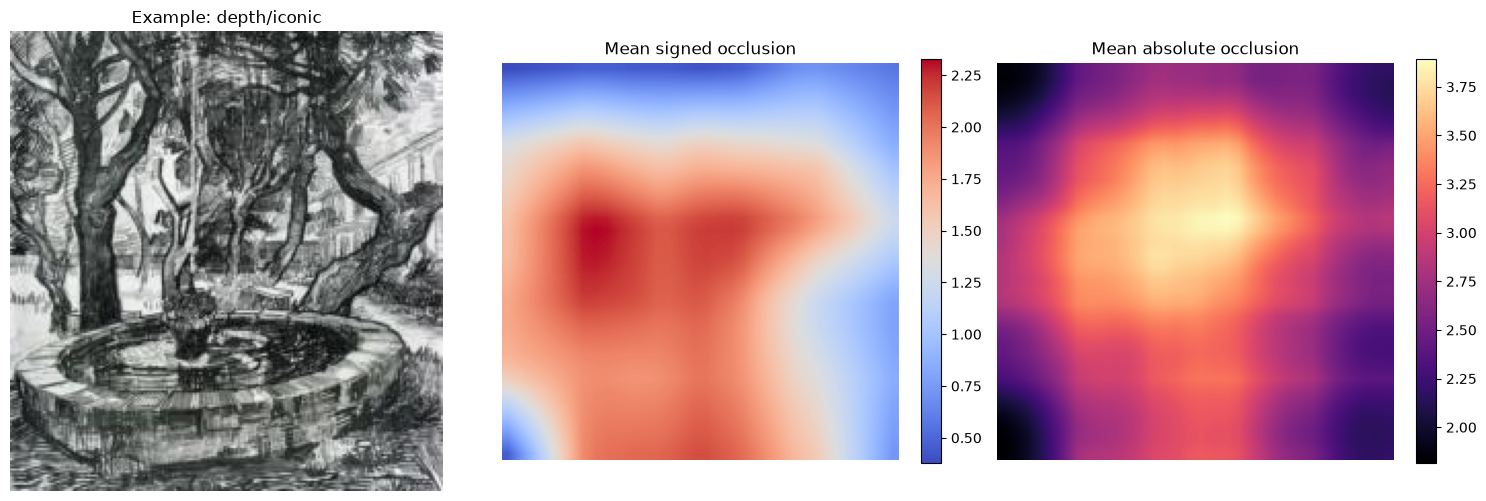

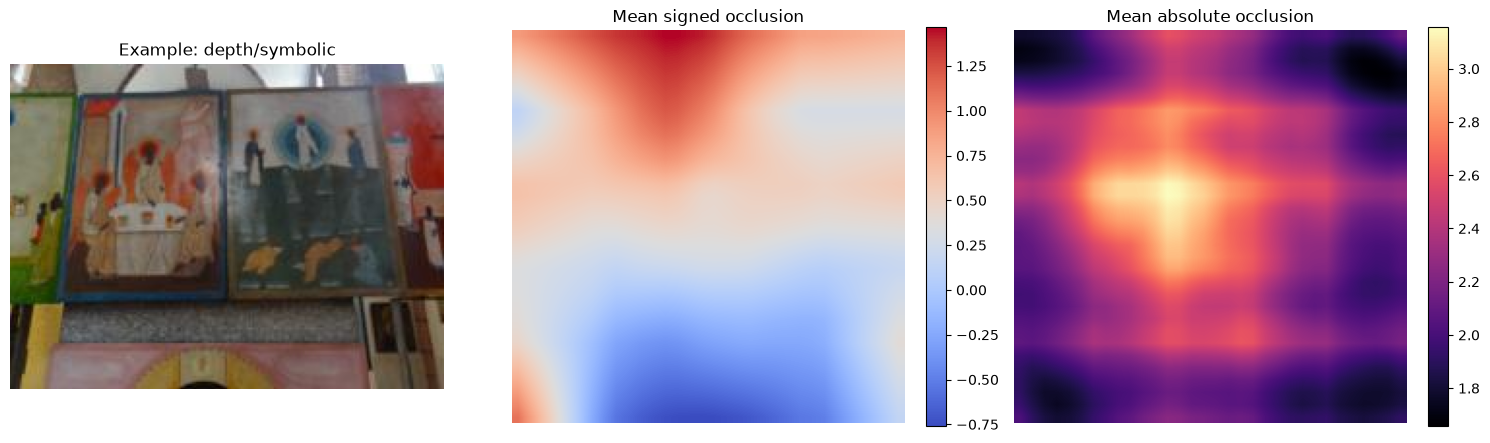

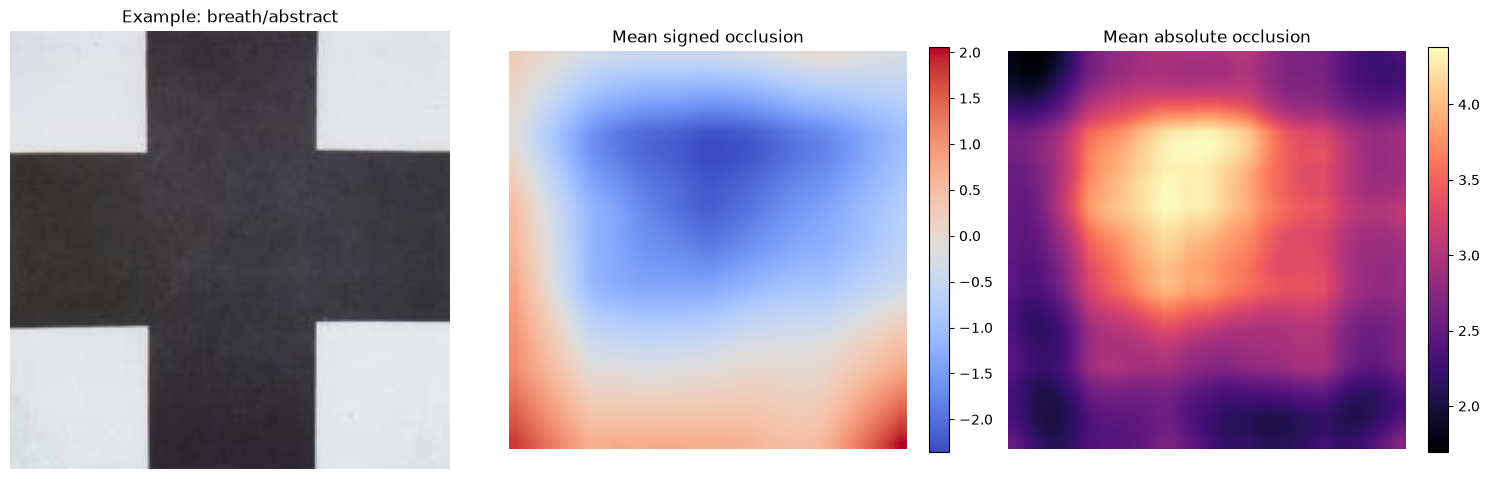

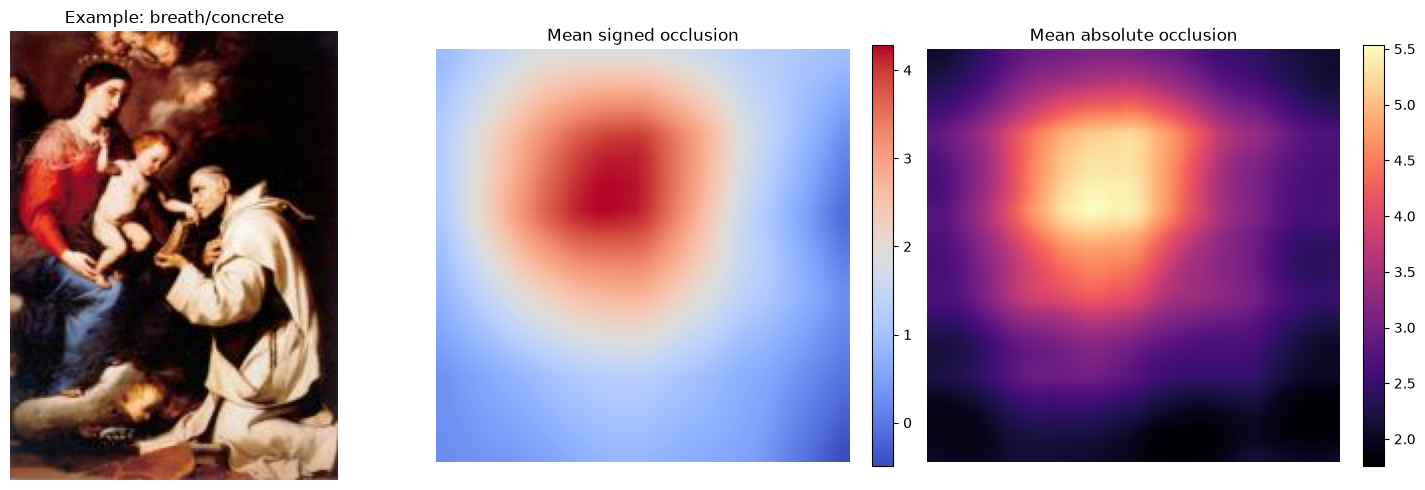

In [205]:
for focus in categories:
    for category in categories[focus]:
        image_path = occlusion_metrics_df[(occlusion_metrics_df["focus"] == focus) & (occlusion_metrics_df["category"] == category) ].sample().iloc[0]["path"]
        show_aggregate_occlusion(
            occlusion_metrics_df,
            focus=focus,
            category=category,
            image_path = image_path
        )